# Patient 1 

In this jupyter notebook the data of patient 1 is loaded, inspected and processed. 

### Import and load the data

In [1]:
# Imports
import mne
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split, cross_val_score 
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
import sklearn.metrics as metrics
import scipy as sp
import scipy.stats as stats
import warnings

# Turn off warnings (that most likely occur from ToeplitzLDA)
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=RuntimeWarning)
mne.set_log_level('WARNING')



In [2]:
# Import and preprocess data
# Some functions below are obtained from assignment 7 (course material)
# TO DO: 15 iterations do not always form a single trial! sometimes it is less. Adjust the code

def load_and_preprocess_raw(header_file, filter_band=(0.5, 16)):
    non_eeg_channels = ["EOGvu", "x_EMGl", "x_GSR", "x_Respi", "x_Pulse", "x_Optic"]
    raw = mne.io.read_raw_brainvision(header_file, misc=non_eeg_channels, preload=True)
    raw.set_montage("standard_1020")
    raw.filter(*filter_band, method="iir")
    raw.pick_types(eeg=True)
    return raw

def epoch_raw(raw, decimate=10):
    target_ids = list(range(111, 117))     # [111, 112, 113, 114, 115, 116]
    non_target_ids = list(range(101, 107)) # [101, 102, 103, 104, 105, 106]

    event_id = {f"Word_{i-110}/Target": i for i in target_ids}
    # {'Word_1/Target': 111, 'Word_2/Target': 112, 'Word_3/Target': 113, 'Word_4/Target': 114, 'Word_5/Target': 115, 'Word_6/Target': 116}
    
    event_id.update({f"Word_{i-100}/NonTarget": i for i in non_target_ids})
    # Same idea for non targets
    
    evs = mne.events_from_annotations(raw)[0]
    print(evs.shape) # e.g. (548,3)
    # print(evs)
    # e.g.
    # [[    0      0  99999]
    # [  4688      0    203]
    # [  9436      0    103]
    # ...
    # [267206      0    106]
    # [267559      0    103]
    # [270989      0    255]]

    # Turn off baseline correction 
    epoch = mne.Epochs(raw, events=evs, event_id=event_id, decim=decimate,
                       proj=False, tmax=1, baseline=None)
    return epoch

# added
def all_have_same_condition(data_path, show_conditions = False):
    """ Checks if all runs within a session have the same condition (6D vs HP, 350 vs 250)"""

    # data_path = "data_p1/P1_S3/anonymized" 
    data_dir = Path.cwd() / data_path
    header_files = data_dir.glob("auditoryAphasia*.vhdr") 
    header_files_list = list(header_files) # convert generator object into list
    header_files_names = [header.name for header in header_files_list] # obtain all headers as strings

    # parse condition of all header files (i.e., all runs)
    header_conditions_1 = [header.split("_")[1] for header in header_files_names] # first condition: 6D or HP
    header_conditions_2 = [header.split("_")[2] for header in header_files_names] # second condition: 350 or 250

    if show_conditions:
        print(header_conditions_1)
        print(header_conditions_2)

    return len(set(header_conditions_1))==1 and len(set(header_conditions_2))==1

# added
def n_iterations(raw_data):
    """
    For a single run containing 6 trials, compute for each trial the nr of iterations used (this is not always 15!)
    Returns a list of 6 elements
    """

    evs = mne.events_from_annotations(raw_data)[0] 
    markers = evs[:,2] # list all event_ids

    # obtain all unique event markers
    uniques, first_indices, counts = np.unique([x for x in markers], return_index=True, return_counts=True)

    # Only keep starting markers [200, 201, 202, 203, 204, 205] and the trial end marker 255
    only_starter_markers = [x for x in uniques if x>199 and x<206]
    only_starter_markers_indices = [first_indices[np.where(uniques==x)][0] for x in uniques if x>199 and x<206 or x==255]

    # Sort the markers according to their stimulus onset order in the trial
    sorted_starter_markers = [x for _,x in sorted(zip(only_starter_markers_indices,only_starter_markers))] 
    sorted_starter_markers_indices = np.sort(only_starter_markers_indices)

    stimuli_per_trial = np.diff(sorted_starter_markers_indices)-1
    iterations_per_trial = stimuli_per_trial/6

    return iterations_per_trial

# added
def load_complete_session(data_path):
    """Load data of a complete session; store loaded data in trials"""

    # data_dir = Path.cwd() / "data_p1/P1_S1/anonymized" 
    data_dir = Path.cwd() / data_path
    header_files = data_dir.glob("auditoryAphasia*.vhdr") # assuming the condition within a session is the same

    # added: check whether the conditions within a session is the same for all runs
    print("All conditions of this session are the same: ",all_have_same_condition(data_path))

    # Load the data, preprocess and slice it into epochs
    epochs = list()

    # added: per run, store how many iterations were used for every trial in that run
    all_trial_iterations = list() 
    print("Number of iterations per trial:")
    run_count = 0 # added to keep track of runs

    for f in header_files:
        raw_data = load_and_preprocess_raw(f)
        epochs.append(epoch_raw(raw_data))

        # added
        iterations_per_trial = n_iterations(raw_data) # obtain list with nr of iterations per trial for all six trials;
        print("Run {}: {}".format(run_count,iterations_per_trial))
        all_trial_iterations.append(iterations_per_trial.astype(int)) # store this per-run list 
        run_count+=1

    # Overwrite epochs list to save memory
    epochs = mne.concatenate_epochs(epochs) 

    # Combine 6 epochs into a single iteration (6 stimuli together form a single iteration)
    iterations = [epochs[i:i+6] for i in np.arange(0, epochs.events.shape[0],6)] # for loop goes from 0 to final epoch in steps of 6

    # Assert that each iteration contains exactly 1 Target
    assert all([len(iteration["Target"]) == 1 for iteration in iterations]), "Number of targets in single iterations is unequal to 1."

    # Old (of assignment 7) and incorrect for this dataset:
    # The assumption was that 15 iterations form a single trial
    # trials = [iterations[i:i+15] for i in np.arange(0,len(iterations),15)] # [  0  15  30  45 ... 465 480 495]

    # Correct: It is not always the case that 15 iterations form a single trial. Sometimes less iterations were recorded, due to dynamic stopping
    # Group the correct amount of iterations per trial
    trials = []
    all_trial_iterations = np.concatenate(all_trial_iterations) # flatten all per-run lists to a single 1D array
    idx = 0
    for n_iters in all_trial_iterations:
        trials.append(iterations[idx : idx + n_iters])
        idx += n_iters

    return trials


In [165]:
# added this whole block
# Object serialization (storing objects with pickle)
import pickle
import os
import re

# Example usage of pickl (to be removed) -----------------------------------------
# test_list = ["Hi", "this", "is", "a", "test"]
# with open("test.pkl",'wb') as f:
#     pickle.dump(test_list,f) # store the list
# f.close()    
# with open("test.pkl", 'rb') as f:
#     test_list_loaded = pickle.load(f) # load the list
# f.close()    
# print(test_list)
# print(test_list_loaded)
# --------------------------------------------------------------------------------

## Functions to store data in pickl files

def safe_filename(session_path):
    """replace / and \\ in data paths by underscores (so it can be saved in the cache folder)"""
    return re.sub(r"[\\/]", "_", session_path)

# load the current trials either for the first time, saving it as a .pkl or directly load from a .pkl file 
# Note: when changing something in the loading/preprocessing, the stored pickl files should be removed as they are outdated.
# to do: figure out of the note above can be done automatically 
def load_session_chached(session_path, cache_dir="cache/"):
    os.makedirs(cache_dir, exist_ok=True)
    safe_name = safe_filename(session_path=session_path) # replace \ and / by _
    print("Loading file: ",safe_name)
    cache_path = os.path.join(cache_dir, safe_name + ".pkl") # save .pkl file
    print("Corresponding .pkl file: ",cache_path)

    # check if a .pkl file for that session already exists
    if os.path.exists(cache_path):
        print("A .pkl file already exists. Loading the data from {}".format(cache_path))
        with open(cache_path, 'rb') as f:
            trials = pickle.load(f)

    # if not, then load the data and store it in a new .pkl file 
    else:
        print("A .pkl file does not exist yet. Loading the data and creating {}... (this might take a few mins)".format(cache_path))
        trials = load_complete_session(session_path)  
        with open(cache_path, 'wb') as f:
            pickle.dump(trials, f)
            
    return trials



In [166]:
data_path_test = "data_p1/P1_S3/anonymized" 
trials_s1 = load_session_chached(data_path_test)
# for p1 s1, first runtime is 3-4 min
# for p1 s1, second runtime is 3 s

print(len(trials_s1))
print(all_have_same_condition(data_path_test, show_conditions=True))


Loading file:  data_p1_P1_S3_anonymized
Corresponding .pkl file:  cache/data_p1_P1_S3_anonymized.pkl
A .pkl file does not exist yet. Loading the data and creating cache/data_p1_P1_S3_anonymized.pkl... (this might take a few mins)
All conditions of this session are the same:  True
Number of iterations per trial:
(507, 3)
Run 0: [15.  8. 15. 15. 15. 15.]
(548, 3)
Run 1: [15. 15. 15. 15. 15. 15.]
(542, 3)
Run 2: [15. 15. 15. 14. 15. 15.]
(506, 3)
Run 3: [15.  8. 15. 15. 15. 15.]
(464, 3)
Run 4: [15.  8.  8. 15. 15. 15.]
(542, 3)
Run 5: [15. 15. 15. 15. 14. 15.]
(518, 3)
Run 6: [10. 15. 15. 15. 15. 15.]
(548, 3)
Run 7: [15. 15. 15. 15. 15. 15.]
(548, 3)
Run 8: [15. 15. 15. 15. 15. 15.]
(548, 3)
Run 9: [15. 15. 15. 15. 15. 15.]
(518, 3)
Run 10: [15. 15. 15. 15. 15. 10.]
(536, 3)
Run 11: [15. 15. 15. 13. 15. 15.]
(488, 3)
Run 12: [15. 15. 12. 15. 15.  8.]
(482, 3)
Run 13: [15. 15. 10. 15. 15.  9.]
84
['6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D']
['350',

In [3]:
# Printing the objects for visualisation
print("raw_data = ",raw_data)
print("\nepochs = \n",epochs)
print("\nlen(epochs) = ", len(epochs))

#print("\n iterations[0] = \n",iterations[0])
print("len(iterations) = ", len(iterations), " (each consists of 6 epochs)")
print("len(trials) = ", len(trials), " (each consists of 15 iterations)")

raw_data =  <RawBrainVision | auditoryAphasia_HP_short_250_Block2_Run4.eeg, 63 x 216360 (216.4 s), ~104.1 MiB, data loaded>

epochs = 
 <EpochsArray | 4320 events (all good), -0.2 – 1 s (baseline off), ~251.3 MiB, data loaded,
 'Word_1/Target': 120
 'Word_2/Target': 120
 'Word_3/Target': 120
 'Word_4/Target': 120
 'Word_5/Target': 120
 'Word_6/Target': 120
 'Word_1/NonTarget': 600
 'Word_2/NonTarget': 600
 'Word_3/NonTarget': 600
 'Word_4/NonTarget': 600
 and 2 more events ...>

len(epochs) =  4320
len(iterations) =  720  (each consists of 6 epochs)
len(trials) =  48  (each consists of 15 iterations)


In [96]:
# Printing the objects for visualisation
print("raw_data = ",raw_data)
print("\nepochs = \n",epochs)
print("\nlen(epochs) = ", len(epochs))

#print("\n iterations[0] = \n",iterations[0])
print("len(iterations) = ", len(iterations), " (each consists of 6 epochs)")
print("len(trials) = ", len(trials), " (each consists of 15 iterations)")

raw_data =  <RawBrainVision | auditoryAphasia_6D_350_Block5_Run3.eeg, 31 x 247980 (248.0 s), ~58.7 MiB, data loaded>

epochs = 
 <EpochsArray | 8892 events (all good), -0.2 – 1 s (baseline off), ~254.5 MiB, data loaded,
 'Word_1/Target': 229
 'Word_2/Target': 274
 'Word_3/Target': 237
 'Word_4/Target': 248
 'Word_5/Target': 234
 'Word_6/Target': 260
 'Word_1/NonTarget': 1253
 'Word_2/NonTarget': 1208
 'Word_3/NonTarget': 1245
 'Word_4/NonTarget': 1234
 and 2 more events ...>

len(epochs) =  8892
len(iterations) =  1482  (each consists of 6 epochs)
len(trials) =  48  (each consists of 15 iterations)


### Dataset

For patient 1, 18 sessions were recorded, of which session 1, 2, and 18 are offline, and sessions 3-17 are online. Each session contains a varying number of blocks. Each block usually contains 6 runs. However, the last block of a session may contain less runs.

For every run a `.eeg`, `.vhdr` and `.vmrk` file is provided. 

The `.vhdr` file of P1, S1, Block1, Run1 contains the following information:
- number of channels: 69
- sampling rate: 1000 Hz
- frequency range: [0-250 Hz]
- the channels are the exact same as of the data of assignment 7.

The following channels are non-EEG channels (description from A7):
* The EMG channel records an electromyogram. This is muscle activity.
* The GSR channel records the galvanic skin response. This is sweat gland activity which is indicative of stress levels and excitation.
* The Respi channel records respiration activity.
* The Pulse channel records the heart pulses by shining a red light on the finger and recording how much of it is reflected back.
* The Optic channel is an optical sensor focused on a portion of the screen that flashes every time an event happens in order to detect potential interference/delay between the time point the computer issues a stimulus and the time the stimulus is actually presented on the screen to the user.

Some of these channels can be used to remove artefacts from the EEG signal and better phase-locking the signals. For the experiment in assignment 7 though they aren't relevant. Is that also the case for my thesis project?

In the `.vhdr` files there is also the resolution ( $\mu V$ steps) of each channel. The ``S o f t w a r e  F i l t e r s`` (line 177) is different from that of A7. In A7, the impedance (kOhm) per channel is provided, while in the patient data this information is replaced by `???`.

In the `.vmrk` file marker information is found about the events.



## Session 3
First load and preprocess the data

Then measure classification performance offline

Then measure classification performance in an online simulation


### load & preprocess the data

In [10]:
# Import and preprocess data
# Functions below are obtained from assignment 7 (course material)

def load_and_preprocess_raw(header_file, filter_band=(0.5, 16)):
    non_eeg_channels = ["EOGvu", "x_EMGl", "x_GSR", "x_Respi", "x_Pulse", "x_Optic"]
    raw = mne.io.read_raw_brainvision(header_file, misc=non_eeg_channels, preload=True)
    raw.set_montage("standard_1020")
    raw.filter(*filter_band, method="iir")
    raw.pick_types(eeg=True)
    return raw

def epoch_raw(raw, decimate=10):
    target_ids = list(range(111, 117))     # [111, 112, 113, 114, 115, 116]
    non_target_ids = list(range(101, 107)) # [101, 102, 103, 104, 105, 106]

    event_id = {f"Word_{i-110}/Target": i for i in target_ids}
    # {'Word_1/Target': 111, 'Word_2/Target': 112, 'Word_3/Target': 113, 'Word_4/Target': 114, 'Word_5/Target': 115, 'Word_6/Target': 116}
    
    event_id.update({f"Word_{i-100}/NonTarget": i for i in non_target_ids})
    # Same idea for non targets
    
    evs = mne.events_from_annotations(raw)[0]

    #print(evs.shape)

    # Turn off baseline correction 
    epoch = mne.Epochs(raw, events=evs, event_id=event_id, decim=decimate,
                       proj=False, tmax=1, baseline=None)
    return epoch

# Get the data path of session 1
data_dir = Path.cwd() / "data_p1/P1_S3/anonymized" 
header_files = data_dir.glob("auditoryAphasia*.vhdr")


counter = 0 # to be removed
raw_data_storage = list() # added for insight - (to be removed later)

# Load the data, preprocess and slice it into epochs
epochs = list()
for f in header_files:
    raw_data = load_and_preprocess_raw(f)
    epochs.append(epoch_raw(raw_data))

    raw_data_storage.append(raw_data) # added for insight - (to be removed later)
    counter+=1 # to be removed

# Overwrite epochs list to save memory
epochs = mne.concatenate_epochs(epochs) # len(epochs) = 3240

# Combine 6 epochs into a single iteration (6 stimuli together form a single iteration)
iterations = [epochs[i:i+6] for i in np.arange(0, epochs.events.shape[0],6)] # for loop goes from 0 to 3234 in steps of 6

# Assert that each iteration contains exactly 1 Target
assert all([len(iteration["Target"]) == 1 for iteration in iterations]), "Number of targets in single iterations is unequal to 1."

# 15 iterations form a single trial
# TO DO: This should change!! it is NOT the case that 15 iterations always form a trial!

trials = [iterations[i:i+15] for i in np.arange(0,len(iterations),15)]

(507, 3)
[[     0      0  99999]
 [  7489      0    206]
 [  7490      0    202]
 ...
 [290836      0    104]
 [291189      0    103]
 [300666      0    255]]
(548, 3)
[[     0      0  99999]
 [  6231      0    204]
 [ 12941      0    106]
 ...
 [296285      0    106]
 [296638      0    102]
 [305542      0    255]]
(542, 3)
[[     0      0  99999]
 [  6195      0    205]
 [ 11883      0    105]
 ...
 [295983      0    106]
 [296335      0    104]
 [305320      0    255]]
(506, 3)
[[     0      0  99999]
 [  6266      0    200]
 [ 11038      0    111]
 ...
 [286171      0    116]
 [286524      0    104]
 [295542      0    255]]
(464, 3)
[[     0      0  99999]
 [  6283      0    201]
 [ 10821      0    112]
 ...
 [272248      0    101]
 [272600      0    105]
 [281628      0    255]]
(542, 3)
[[     0      0  99999]
 [  6219      0    203]
 [ 10957      0    106]
 ...
 [298105      0    101]
 [298459      0    102]
 [307386      0    255]]
(518, 3)
[[     0      0  99999]
 [  6296     

In [19]:
# Printing the objects for visualisation
print(len(raw_data_storage))
print(raw_data_storage[0].info)

print("raw_data = ",raw_data)
print("\nepochs = \n",epochs)
print("\nlen(epochs) = ", len(epochs))

#print("\n iterations[0] = \n",iterations[0])
print("len(iterations) = ", len(iterations), " (each consists of 6 epochs)")
print("len(trials) = ", len(trials), " (each consists of 15 iterations)")

14
<Info | 8 non-empty values
 bads: []
 ch_names: Fp1, Fp2, F3, F4, C3, C4, P3, P4, O1, O2, F7, F8, T7, T8, P7, ...
 chs: 31 EEG
 custom_ref_applied: False
 dig: 34 items (3 Cardinal, 31 EEG)
 highpass: 0.5 Hz
 lowpass: 16.0 Hz
 meas_date: 1920-01-01 15:06:42 UTC
 nchan: 31
 projs: []
 sfreq: 1000.0 Hz
>
raw_data =  <RawBrainVision | auditoryAphasia_6D_350_Block3_Run2.eeg, 31 x 286320 (286.3 s), ~67.8 MiB, data loaded>

epochs = 
 <EpochsArray | 7182 events (all good), -0.2 – 1 s (baseline off), ~205.6 MiB, data loaded,
 'Word_1/Target': 205
 'Word_2/Target': 207
 'Word_3/Target': 208
 'Word_4/Target': 196
 'Word_5/Target': 195
 'Word_6/Target': 186
 'Word_1/NonTarget': 992
 'Word_2/NonTarget': 990
 'Word_3/NonTarget': 989
 'Word_4/NonTarget': 1001
 and 2 more events ...>

len(epochs) =  7182
len(iterations) =  1197  (each consists of 6 epochs)
len(trials) =  80  (each consists of 15 iterations)


In [97]:
data_path_test = "data_p1/P1_S3/anonymized" 
trials_s3 = load_session_chached(data_path_test)
# for p1 s1, first runtime is ... min
# for p1 s1, second runtime is ...

print(len(trials_s3))

data_p1_P1_S3_anonymized
cache/data_p1_P1_S3_anonymized.pkl
(507, 3)
[[     0      0  99999]
 [  7489      0    206]
 [  7490      0    202]
 ...
 [290836      0    104]
 [291189      0    103]
 [300666      0    255]]
(548, 3)
[[     0      0  99999]
 [  6231      0    204]
 [ 12941      0    106]
 ...
 [296285      0    106]
 [296638      0    102]
 [305542      0    255]]
(542, 3)
[[     0      0  99999]
 [  6195      0    205]
 [ 11883      0    105]
 ...
 [295983      0    106]
 [296335      0    104]
 [305320      0    255]]
(506, 3)
[[     0      0  99999]
 [  6266      0    200]
 [ 11038      0    111]
 ...
 [286171      0    116]
 [286524      0    104]
 [295542      0    255]]
(464, 3)
[[     0      0  99999]
 [  6283      0    201]
 [ 10821      0    112]
 ...
 [272248      0    101]
 [272600      0    105]
 [281628      0    255]]
(542, 3)
[[     0      0  99999]
 [  6219      0    203]
 [ 10957      0    106]
 ...
 [298105      0    101]
 [298459      0    102]
 [307386   

In [121]:
# Printing the objects for visualisation
print(len(epochs))
print(len(trials_s3))
epochs_s3 = [[epoch for epoch in iteration] for iteration in trials_s3]
iterations_s3 = [iterations for iteration in trials_s3]
# test_s3 = [*trials_s3]
# print(len(test_s3))
test_list_s3 = []
for item in trials_s3:
    test_list_s3.extend(item)

print(len(test_list_s3))
print(80*15)
print(len(trials_s3[-1])) # the final trial of session 3 contains 12 iterations
print(np.unique(trials))
#print(len(epochs_s3))
#print(iterations_s3[0])
#print(len(iterations_s3))
print("raw_data = ",raw_data)
print("\nepochs = \n",epochs)
print("\nlen(epochs) = ", len(epochs))

#print("\n iterations[0] = \n",iterations[0])
print("len(iterations) = ", len(iterations), " (each consists of 6 epochs)")
print("len(trials) = ", len(trials), " (each consists of 15 iterations)")

8892
80
1197
1200
12
raw_data =  <RawBrainVision | auditoryAphasia_6D_350_Block5_Run3.eeg, 31 x 247980 (248.0 s), ~58.7 MiB, data loaded>

epochs = 
 <EpochsArray | 8892 events (all good), -0.2 – 1 s (baseline off), ~254.5 MiB, data loaded,
 'Word_1/Target': 229
 'Word_2/Target': 274
 'Word_3/Target': 237
 'Word_4/Target': 248
 'Word_5/Target': 234
 'Word_6/Target': 260
 'Word_1/NonTarget': 1253
 'Word_2/NonTarget': 1208
 'Word_3/NonTarget': 1245
 'Word_4/NonTarget': 1234
 and 2 more events ...>

len(epochs) =  8892
len(iterations) =  1482  (each consists of 6 epochs)
len(trials) =  48  (each consists of 15 iterations)


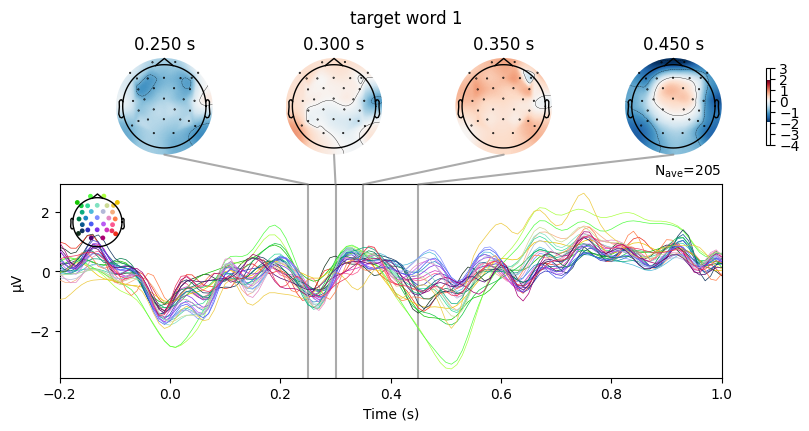

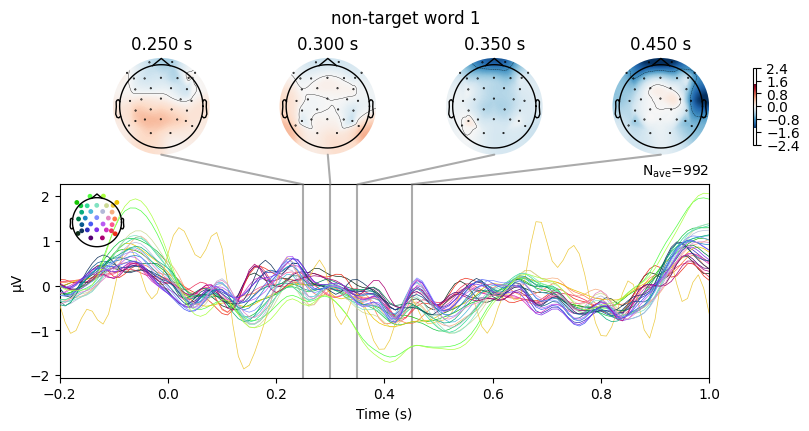

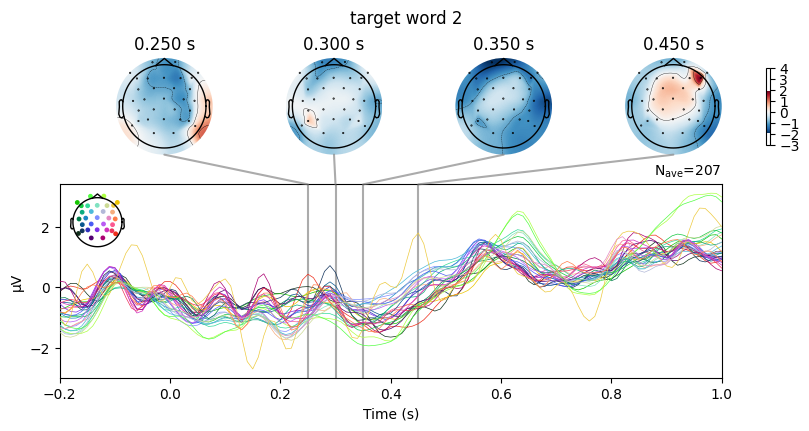

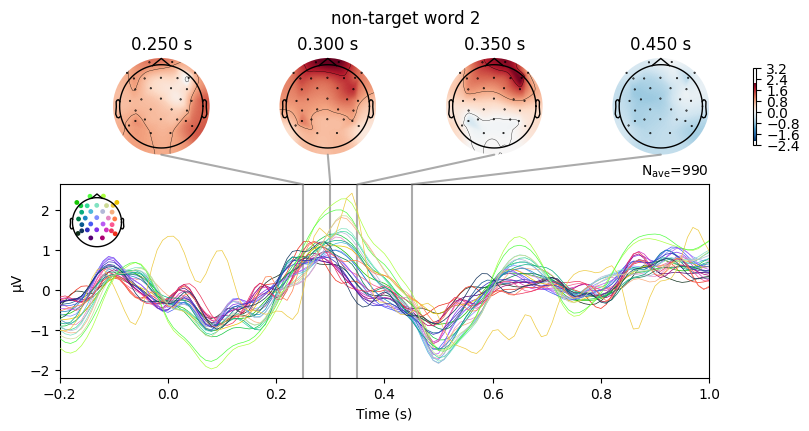

In [6]:
scalp_times = (0.25, 0.30, 0.35, 0.45)
for i in np.arange(1,6):
    if i < 3:     # to not have a massive notebook
        epochs[f'Word_{i}']["Target"].average().plot_joint(title=f'target word {i}', times=scalp_times)
        epochs[f'Word_{i}']["NonTarget"].average().plot_joint(title=f'non-target word {i}', times=scalp_times)

plt.show()


#### Comparing LDA - SLDA - BTLDA
Using the data of session 3

In [ ]:
# comparing LDA - BT-LDA - sLDA
# data is in channel prime order
# evaulation method added from Jan's example_toeplitz_lda_simple.py

from sklearn.pipeline import make_pipeline
from sklearn.metrics import balanced_accuracy_score, roc_auc_score
from toeplitzlda.classification import ToeplitzLDA
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# See cell block in dump file for documentation on how this function works
def get_jumping_means(epo, boundaries):
    shape_orig = epo.get_data().shape
    X = np.zeros((shape_orig[0], shape_orig[1], len(boundaries)-1))
    for i in range(len(boundaries)-1):
        idx = epo.time_as_index((boundaries[i], boundaries[i+1]))
        idx_range = list(range(idx[0], idx[1]))
        X[:,:,i] = epo.get_data()[:,:,idx_range].mean(axis=2)
    return X

def compare_auc_single_trial_interval(start=0, stop=12, test_size=0.2, only_auc = True, ival_bounds = np.array([0.1, 0.2, 0.3, 0.4, 0.5]), plot_roc_curves = True):
    """
    compares LDA vs sLDA vs BT-LDA on calibration data
    
    calibration data is determined by a selection of trials [start - stop], e.g. [0-12]
    note that this is not robust! the interval matters. You can check this by passing different values for [start - stop]
    The full dataset here is the selected interval of calibration data. This interval will be split with sklearn's train_test_split method.

    input:
    - start: first trial to take as calibration data
    - stop: last trial to take as calibration data
    - test_size: the test part in the ratio train:test when splitting the calibration data. 
    - only_auc: if True, only the auc scores are printed for all three classifiers. If False, then the balanced auc scores are printed too.
    - ival_bounds: time interval boundaries to average the raw calibration trials over
    - plot_roc_curves: if True, also plot the ROC curves. if False, then only the AUC scores are printed. 
    """

    raw_calibration_trials = trials[start:stop] # change start & stop trial
    # online_trials = trials[12:] 
    clf_ival_boundaries = ival_bounds
    calibration_trials = np.array([[get_jumping_means(iteration, clf_ival_boundaries) for iteration in trial] for trial in raw_calibration_trials])
    calibration_trials_reshaped = np.array([
        [epochs.transpose(0, 2, 1) for epochs in trial] # make channel prime
        for trial in calibration_trials
    ])

    # calibration_trials has shape (12, 15, 6, 63, 4) --> calibration_trials_reshaped has shape (12, 15, 6, 4, 63)

    # finish X and y to feed into classifier
    calibration_stimuli = np.reshape(calibration_trials_reshaped, (np.prod(calibration_trials_reshaped.shape[0:3]),-1)) # new shape: (1080, 252)
    calibration_labels = np.array([[[[1 if event > 107 else 0] for event in iteration.events[:,2]] for iteration in trial] for trial in raw_calibration_trials]).flatten() # shape (1080,), contains only 0's and 1's
    #X_train, X_test, y_train, y_test = train_test_split(calibration_stimuli, calibration_labels, test_size=0.1, shuffle=False)
    # Exp_6
    X_train, X_test, y_train, y_test = train_test_split(calibration_stimuli, calibration_labels, test_size=test_size, shuffle=False)

    # Evaluation of Jan's simple toeplitz example script

    print("AUC scores computed using a single train_test_split with test_size = {}".format(test_size))

    ### LDA
    clf_lda = make_pipeline(LDA(),)
    clf_lda.fit(X_train,y_train)

    y_df = clf_lda.decision_function(X_test)
    roc_auc_lda = roc_auc_score(y_test, y_df)
    y_pred = clf_lda.predict(X_test)
    bal_acc_auc_lda = balanced_accuracy_score(y_test, y_pred)

    if only_auc:
        print("AUC LDA: ", roc_auc_lda)
    else:
        print("LDA scores with channel prime data")
        print("roc_auc: ",roc_auc_lda)
        print("bal_acc_auc: ",bal_acc_auc_lda)

    ### sLDA
    clf_slda = make_pipeline(LDA(solver='lsqr', shrinkage='auto'),)
    clf_slda.fit(X_train,y_train)

    y_df = clf_slda.decision_function(X_test)
    roc_auc_slda = roc_auc_score(y_test, y_df)
    y_pred = clf_slda.predict(X_test)
    bal_acc_auc_slda = balanced_accuracy_score(y_test, y_pred)

    if only_auc:
        print("AUC SLDA: ", roc_auc_slda)
    else:     
        print("\nsLDA scores with channel prime data")
        print("roc_auc: ",roc_auc_slda)
        print("bal_acc_auc: ",bal_acc_auc_slda)

    ### BT-LDA
    from toeplitzlda.classification import (
        EpochsVectorizer,
        ShrinkageLinearDiscriminantAnalysis,
        ToeplitzLDA,
    )

    #nch = 31
    nch = (trials[0][0]).info["nchan"]
    clf_btlda = make_pipeline(
        ToeplitzLDA(n_channels=nch),
    )
    clf_btlda.fit(X_train,y_train)

    y_df = clf_btlda.decision_function(X_test)
    roc_auc_btlda = roc_auc_score(y_test, y_df)
    y_pred = clf_btlda.predict(X_test)
    bal_acc_auc_btlda = balanced_accuracy_score(y_test, y_pred)

    if only_auc:
        print("AUC BT-LDA: ", roc_auc_btlda)
    else:    
        print("\nBT-LDA scores with channel prime data")
        print("roc_auc: ",roc_auc_btlda)
        print("bal_acc_auc: ",bal_acc_auc_btlda)


    # ------------------------------------------------------------------------------------------------------------
    #
    # comparing LDA - BT-LDA - sLDA using other evaluation method
    # Evaluation of ex. 3
    if plot_roc_curves:
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))  # 1 row, 3 columns

        ### LDA

        lda = LDA()
        ldaclf = lda.fit(X_train, y_train)
        fpr_lda, tpr_lda, thresholds_lda = metrics.roc_curve(y_test,ldaclf.decision_function(X_test)) # Compute signed distance of stimulus to decision boundary

        metrics.RocCurveDisplay(fpr=fpr_lda, tpr=tpr_lda).plot(ax=axes[0])
        axes[0].plot([0, 1],[0,1], '--') 
        axes[0].legend(['ROC (area = %0.5f)' % metrics.auc(fpr_lda, tpr_lda), 'area = 0.5'], loc="lower right")
        axes[0].set_title("AUC-ROC of LDA - test_size = {}".format(test_size))

        ### Shrinkage LDA

        slda = LDA(solver='lsqr',shrinkage = 'auto')
        slda.fit(X_train, y_train)

        fpr_slda, tpr_slda, thresholds_slda = metrics.roc_curve(y_test,slda.decision_function(X_test)) # Compute signed distance of stimulus to decision boundary
        metrics.RocCurveDisplay(fpr=fpr_slda, tpr=tpr_slda).plot(ax=axes[1])
        axes[1].plot([0, 1],[0,1], '--')
        axes[1].legend(['ROC (area = %0.5f)' % metrics.auc(fpr_slda, tpr_slda), 'area = 0.5'], loc="lower right")
        axes[1].set_title("AUC-ROC of sLDA - test_size = {}".format(test_size))

        ### BT-LDA

        # TO DO: try to set channel prime to False to let the class fix it vs manually fixing it (as done in assignment 6). See if it gives the same results 
        nch = (trials[0][0]).info["nchan"]
        # nch = 31 (for online sessions) and 61 for offline sessions
        btlda = ToeplitzLDA(n_channels= nch) 
        btlda.fit(X_train, y_train) 

        fpr_btlda, tpr_btlda, thresholds_btlda = metrics.roc_curve(y_test,btlda.decision_function(X_test)) # Compute signed distance of stimulus to decision boundary
        metrics.RocCurveDisplay(fpr=fpr_btlda, tpr=tpr_btlda).plot(ax=axes[2])
        axes[2].plot([0, 1],[0,1], '--')
        axes[2].legend(['ROC (area = %0.5f)' % metrics.auc(fpr_btlda, tpr_btlda), 'area = 0.5'], loc="lower right")
        axes[2].set_title("AUC-ROC of BT-LDA - test_size = {}".format(test_size))
        
        plt.show()


AUC scores computed using a single train_test_split with test_size = 0.2
AUC LDA:  0.5277777777777778
AUC SLDA:  0.47438271604938276
AUC BT-LDA:  0.4966049382716049


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


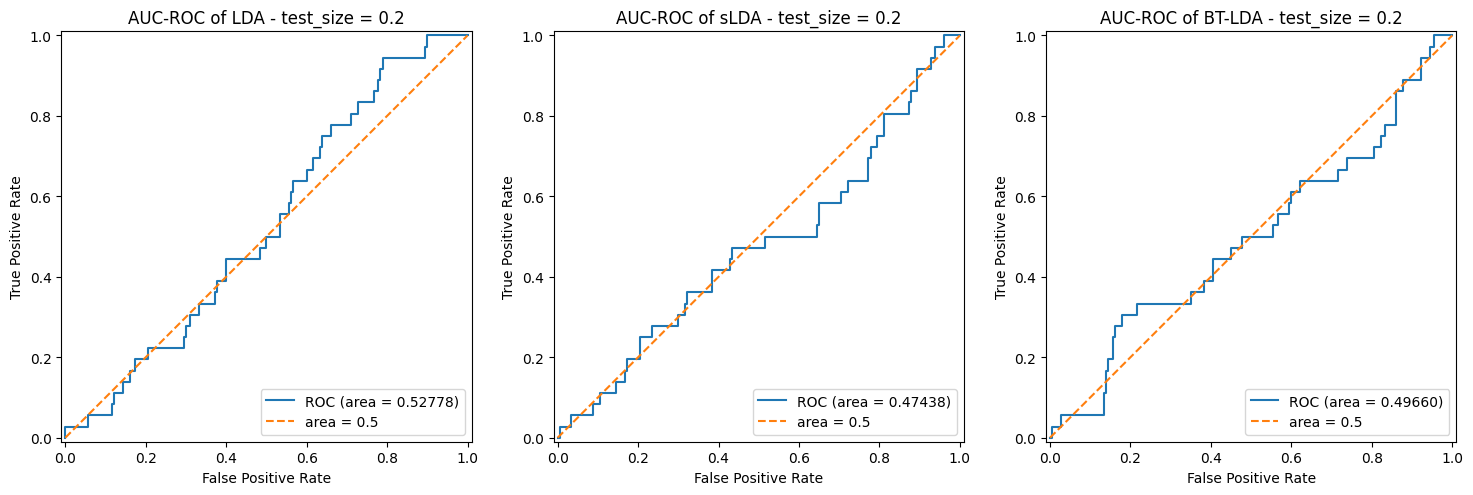

In [29]:
# train_test_split using test_size = 0.2 and test_size = 0.3
# using the time intervals [0.1, 0.2, 0.3, 0.4, 0.5] (Default)
compare_auc_single_trial_interval(0,12,test_size=0.2,plot_roc_curves=True) # trials 0-12 (the first two runs) are used

In [ ]:
# train_test_split using test_size = 0.2 and test_size = 0.3
# using the time intervals [0.1, 0.2, 0.3, 0.4, 0.5] (Default)
compare_auc_single_trial_interval(0,50,test_size=0.2,plot_roc_curves=True) # trials 0-50 are used

## Session 16

In [32]:
# Get the data path of session 1
data_dir = Path.cwd() / "data_p1/P1_S16/anonymized" 
header_files = data_dir.glob("auditoryAphasia*.vhdr")


counter = 0 # to be removed
raw_data_storage = list() # added for insight - (to be removed later)

# Load the data, preprocess and slice it into epochs
epochs = list()
for f in header_files:
    raw_data = load_and_preprocess_raw(f)
    epochs.append(epoch_raw(raw_data))

    raw_data_storage.append(raw_data) # added for insight - (to be removed later)
    counter+=1 # to be removed

# Overwrite epochs list to save memory
epochs = mne.concatenate_epochs(epochs) # len(epochs) = 3240

# Combine 6 epochs into a single iteration (6 stimuli together form a single iteration)
iterations = [epochs[i:i+6] for i in np.arange(0, epochs.events.shape[0],6)] # for loop goes from 0 to 3234 in steps of 6

# Assert that each iteration contains exactly 1 Target
assert all([len(iteration["Target"]) == 1 for iteration in iterations]), "Number of targets in single iterations is unequal to 1."

# 15 iterations form a single trial
trials = [iterations[i:i+15] for i in np.arange(0,len(iterations),15)]

(338, 3)
[[     0      0  99999]
 [  6332      0    201]
 [ 10743      0    105]
 ...
 [236635      0    101]
 [236988      0    103]
 [247670      0    255]]
(326, 3)
[[     0      0  99999]
 [  6342      0    205]
 [ 13052      0    103]
 [ 13405      0    104]
 [ 13758      0    102]
 [ 14111      0    105]
 [ 14464      0    101]
 [ 14817      0    116]
 [ 15169      0    104]
 [ 15523      0    102]
 [ 15876      0    116]
 [ 16229      0    101]
 [ 16582      0    103]
 [ 16934      0    105]
 [ 17288      0    102]
 [ 17641      0    104]
 [ 17994      0    116]
 [ 18347      0    105]
 [ 18700      0    103]
 [ 19053      0    101]
 [ 19406      0    104]
 [ 19760      0    102]
 [ 20113      0    116]
 [ 20465      0    105]
 [ 20818      0    101]
 [ 21171      0    103]
 [ 21525      0    102]
 [ 21877      0    101]
 [ 22230      0    105]
 [ 22583      0    104]
 [ 22936      0    116]
 [ 23289      0    103]
 [ 23643      0    105]
 [ 23995      0    101]
 [ 24348      0 

AUC scores computed using a single train_test_split with test_size = 0.2
AUC LDA:  0.9185185185185185
AUC SLDA:  0.9120370370370371
AUC BT-LDA:  0.9183641975308642


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


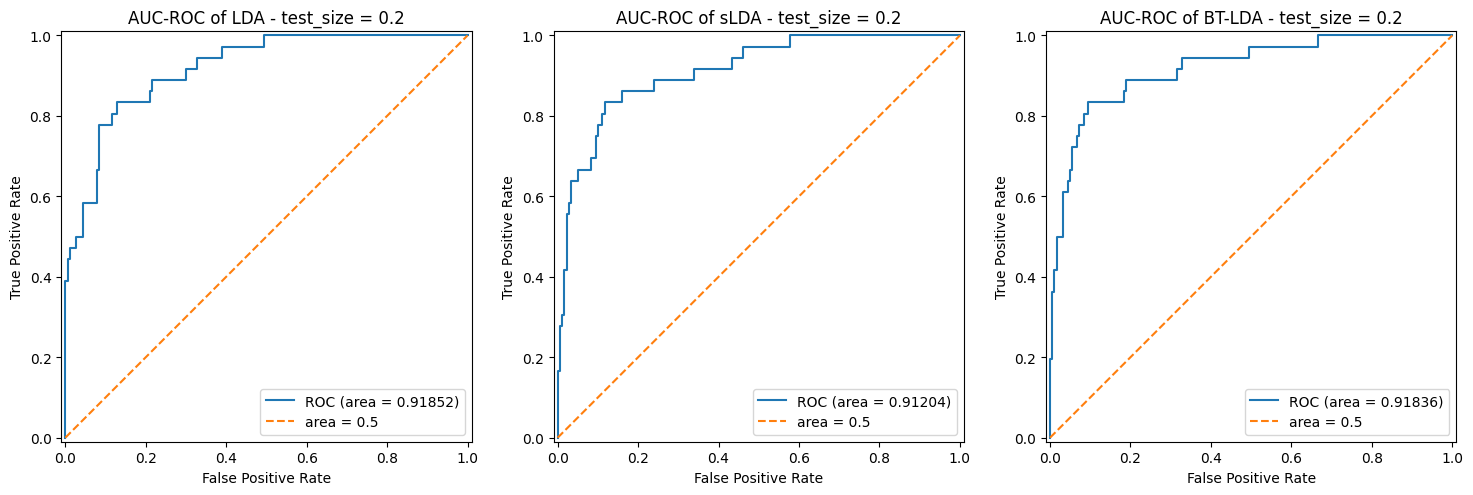

In [33]:
# train_test_split using test_size = 0.2 and test_size = 0.3
# using the time intervals [0.1, 0.2, 0.3, 0.4, 0.5] (Default)
compare_auc_single_trial_interval(0,12,test_size=0.2,plot_roc_curves=True)

In [ ]:
# Cross-validation instead of train_test_split
# LDA vs SLDA vs BT-LDA on calibration data

def compute_auc_with_cv(trials=trials, ival_bounds = np.array([0.1, 0.2, 0.3, 0.4, 0.5]), cv_folds = 4, show_only_mean = True):
    """
    Computes and prints the average AUC score of LDA, SLDA and BTLDA using cross-validation

    input:
    - trials
    - ival_bounds
    - cv_folds
    - show_only_mean: if True, only print the average AUC scores. if False, also print the AUC score of each fold.
    """

    raw_calibration_trials = trials[0:12] # change start & stop trial?
    #online_trials = trials[12:] 
    clf_ival_boundaries = ival_bounds

    calibration_trials = np.array([[get_jumping_means(iteration, clf_ival_boundaries) for iteration in trial] for trial in raw_calibration_trials])
    calibration_trials_reshaped = np.array([
        [epochs.transpose(0, 2, 1) for epochs in trial] # make channel prime
        for trial in calibration_trials
    ])

    # calibration_trials has shape (12, 15, 6, 63, 4) --> calibration_trials_reshaped has shape (12, 15, 6, 4, 63)

    # finish X and y to feed into classifier
    calibration_stimuli = np.reshape(calibration_trials_reshaped, (np.prod(calibration_trials_reshaped.shape[0:3]),-1)) # new shape: (1080, 252)
    calibration_labels = np.array([[[[1 if event > 107 else 0] for event in iteration.events[:,2]] for iteration in trial] for trial in raw_calibration_trials]).flatten() # shape (1080,), contains only 0's and 1's
    X = calibration_stimuli
    y = calibration_labels

    ### LDA
    clf_lda = make_pipeline(LDA(),)
    auc_lda = cross_val_score(clf_lda, X, y, cv=cv_folds, scoring = 'roc_auc')
    if not show_only_mean:
        print("AUC score of LDA, all 4 folds: ",auc_lda)
    print("Mean AUC score of LDA: ", auc_lda.mean())

    ### SLDA
    clf_slda = make_pipeline(LDA(solver='lsqr', shrinkage='auto'),)
    auc_slda = cross_val_score(clf_slda, X, y, cv=cv_folds, scoring = 'roc_auc')
    if not show_only_mean:
        print("AUC score of sLDA, all 4 folds: ",auc_slda)
    print("Mean AUC score of sLDA: ", auc_slda.mean())

    ### BT-LDA
    #nch = 31
    nch = (trials[0][0]).info["nchan"]
    clf_btlda = make_pipeline(
        ToeplitzLDA(n_channels=nch),
    )
    auc_btlda = cross_val_score(clf_btlda, X, y, cv=cv_folds, scoring = 'roc_auc')
    if not show_only_mean:
        print("AUC score of BT-LDA, all 4 folds: ",auc_btlda)
    print("Mean AUC score of BT-LDA: ", auc_btlda.mean())



In [37]:
# LDA vs SLDA vs BT-LDA
clf_ival_boundaries = np.array([0.1, 0.2, 0.3, 0.4, 0.5])

# Using cv
print("Using 4-fold cross-validation:")
compute_auc_with_cv(trials, ival_bounds=clf_ival_boundaries, cv_folds = 4, show_only_mean=True)

Using 4-fold cross-validation:
Mean AUC score of LDA:  0.8785432098765432
Mean AUC score of sLDA:  0.8954814814814814
Mean AUC score of BT-LDA:  0.8997037037037037


## Online


In [40]:
# copied from A7 notebook
#  added 21/04/2025: copied from above + modifications
# modifications:
# - changed clf to ldaclf which is trained on channel prime data (do not apply clf on new, channel prime data as this has not been trained on this structure. i.e., be consistent with the data structure in both fitting and testing/applying)
# - added some comments 
# - changed input to decision_function to be channel-prime through .transpose(0,2,1)
# - added slda and btlda


# added from a nr of blocks above -----------------------------------------------------
    # Run 19/04/2025_Exp_1

clf_ival_boundaries = np.array([0.1, 0.2, 0.3, 0.4, 0.5])
#clf_ival_boundaries = np.array([0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5])

raw_calibration_trials = trials[0:12] # change start & stop trial
online_trials = trials[12:] 

calibration_trials = np.array([[get_jumping_means(iteration, clf_ival_boundaries) for iteration in trial] for trial in raw_calibration_trials])
calibration_trials_reshaped = np.array([
    [epochs.transpose(0, 2, 1) for epochs in trial] # make channel prime
    for trial in calibration_trials
])

# calibration_trials has shape (12, 15, 6, 63, 4) --> calibration_trials_reshaped has shape (12, 15, 6, 4, 63)

# finish X and y to feed into classifier
calibration_stimuli = np.reshape(calibration_trials_reshaped, (np.prod(calibration_trials_reshaped.shape[0:3]),-1)) # new shape: (1080, 252)
calibration_labels = np.array([[[[1 if event > 107 else 0] for event in iteration.events[:,2]] for iteration in trial] for trial in raw_calibration_trials]).flatten() # shape (1080,), contains only 0's and 1's
X = calibration_stimuli
y = calibration_labels


# Evaluation of ex. 3 

### LDA

# lda = LDA()
# ldaclf = lda.fit(X_train, y_train)
ldaclf = make_pipeline(LDA(),)
ldaclf.fit(X,y)

### Shrinkage LDA

# slda = LDA(solver='lsqr',shrinkage = 'auto')
# slda.fit(X_train, y_train)
slda = make_pipeline(LDA(solver='lsqr', shrinkage='auto'),)
slda.fit(X,y)

### BT-LDA

# btlda = ToeplitzLDA(n_channels= 63) 
# btlda.fit(X_train, y_train) 
# nch = 31
nch = (trials[0][0]).info["nchan"]
btlda = make_pipeline(
    ToeplitzLDA(n_channels=nch),
)
btlda.fit(X,y)

# -------------------------------------------------------------------------------


# Extract relevant data, labels and the played words
online_trial_targets = np.array([trial[0]["Target"].events[:,2][0] % 10 for trial in online_trials]) # The target word per trial
online_labels = np.array([[[[1 if event > 107 else 0][0] for event in iteration.events[:,2]] for iteration in trial] for trial in online_trials]) # The location of the target word in the sequence of 6 stimuli per iteration. Note that the order of stimuli differs per iteration.
online_words = np.array([[iteration.events[:,2]%10 for iteration in trial] for trial in online_trials]) # The word ID sequence that is presented per iteration. Note that the order of the presented words differs between iterations.

# 4.1: Predict target/non-target per stimulus.

signed_distances_lda = np.zeros(online_words.shape) # (trials, iterations, words)
signed_distances_slda = np.zeros(online_words.shape) 
signed_distances_btlda = np.zeros(online_words.shape) 
# online_trials has shape (trials, iterations, words/epochs, channels, time_points)
print(clf_ival_boundaries)

p = 0
for t, trial in enumerate(online_trials):
    for i, iteration in enumerate(trial):
        for s, stimulus in enumerate(iteration):
                        
            # changed to channel prime for bt-lda
            signed_distances_lda[t,i,s] = ldaclf.decision_function(get_jumping_means(iteration[s],clf_ival_boundaries).transpose(0,2,1).flatten().reshape(1,-1))[0] # Compute signed distance of stimulus to decision boundary
            
            signed_distances_slda[t,i,s] = slda.decision_function(get_jumping_means(iteration[s],clf_ival_boundaries).transpose(0,2,1).flatten().reshape(1,-1))[0]
            
            # Important note during debugging
            # btlda.decision_function returns an nd array of shape (). To access its value, you have to call .item() additionally, instead of taking the first element via [0] (as done for lda and slda)
            signed_distances_btlda[t,i,s] = btlda.decision_function(get_jumping_means(iteration[s],clf_ival_boundaries).transpose(0,2,1).flatten().reshape(1,-1)).item() 


fpr, tpr, thresholds = metrics.roc_curve(online_labels.flatten(),signed_distances_lda.flatten()) 
auc_fig = metrics.RocCurveDisplay(fpr=fpr, tpr = tpr)
auc_fig.plot()
plt.plot([0, 1],[0,1], '--')
plt.legend(['ROC curve (area = %0.5f)' % metrics.auc(fpr, tpr), 'area = 0.5'], loc="lower right")
plt.title("AUC-ROC Curve of the LDA classifier [online]")
plt.show()


fpr, tpr, thresholds = metrics.roc_curve(online_labels.flatten(),signed_distances_slda.flatten()) 
auc_fig = metrics.RocCurveDisplay(fpr=fpr, tpr = tpr)
auc_fig.plot()
plt.plot([0, 1],[0,1], '--')
plt.legend(['ROC curve (area = %0.5f)' % metrics.auc(fpr, tpr), 'area = 0.5'], loc="lower right")
plt.title("AUC-ROC Curve of the sLDA classifier [online]")
plt.show()


fpr, tpr, thresholds = metrics.roc_curve(online_labels.flatten(),signed_distances_btlda.flatten()) 
auc_fig = metrics.RocCurveDisplay(fpr=fpr, tpr = tpr)
auc_fig.plot()
plt.plot([0, 1],[0,1], '--')
plt.legend(['ROC curve (area = %0.5f)' % metrics.auc(fpr, tpr), 'area = 0.5'], loc="lower right")
plt.title("AUC-ROC Curve of the BT-LDA classifier [online]")
plt.show()



ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (87,) + inhomogeneous part.